In [1]:
from functools import partial

import jax
import jax.numpy as jnp
import mediapy

key = jax.random.PRNGKey(0)

In [2]:
from omni_epic.envs.wall_is_lava import Env
from ppo.wrappers import EpisodeWrapper, AutoResetWrapper, LogWrapper, ClipAction, VecEnv, NormalizeVecObservation, NormalizeVecReward

env = Env()
env = EpisodeWrapper(env, episode_length=1000, action_repeat=1)
env = AutoResetWrapper(env)
env = LogWrapper(env)
env = ClipAction(env)
# env = VecEnv(env)
# env = NormalizeVecObservation(env)
# env = NormalizeVecReward(env, 0.99)

In [3]:
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

num_envs = 16

In [4]:
key, subkey = jax.random.split(key)
env_state = reset_fn(subkey)
images = [env.renderer(env_state)]
for _ in range(200):
	action = jnp.zeros(4)
	# action = action.at[0].set(0.2)
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)
	images.append(env.renderer(env_state))
	print(_, env_state.terminated)

# Move robot
env_state = env.set_polygon_position(env_state, env.robot_idx, jnp.array([10.0, 10.0]))

for _ in range(10):
	action = jnp.zeros(4)
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)
	images.append(env.renderer(env_state))
	print(_, env_state.terminated)

for _ in range(200):
	action = jnp.zeros(4)
	# action = -action.at[3].set(0.2)
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)
	images.append(env.renderer(env_state))
	print(_, env_state.terminated)

0 0.0
1 0.0
2 0.0
3 0.0
4 0.0
5 0.0
6 0.0
7 0.0
8 0.0
9 0.0
10 0.0
11 0.0
12 0.0
13 0.0
14 0.0
15 0.0
16 0.0
17 0.0
18 0.0
19 0.0
20 0.0
21 0.0
22 0.0
23 0.0
24 0.0
25 0.0
26 0.0
27 0.0
28 0.0
29 0.0
30 0.0
31 0.0
32 0.0
33 0.0
34 0.0
35 0.0
36 0.0
37 0.0
38 0.0
39 0.0
40 0.0
41 0.0
42 0.0
43 0.0
44 0.0
45 0.0
46 0.0
47 0.0
48 0.0
49 0.0
50 0.0
51 0.0
52 0.0
53 0.0
54 0.0
55 0.0
56 0.0
57 0.0
58 0.0
59 0.0
60 0.0
61 0.0
62 0.0
63 0.0
64 0.0
65 0.0
66 0.0
67 0.0
68 0.0
69 0.0
70 0.0
71 1.0
72 0.0
73 0.0
74 0.0
75 0.0
76 0.0
77 0.0
78 0.0
79 0.0
80 0.0
81 0.0
82 0.0
83 0.0
84 0.0
85 0.0
86 0.0
87 0.0
88 0.0
89 0.0
90 0.0
91 0.0
92 0.0
93 0.0
94 0.0
95 0.0
96 0.0
97 0.0
98 0.0
99 0.0
100 0.0
101 0.0
102 0.0
103 0.0
104 0.0
105 0.0
106 0.0
107 0.0
108 0.0
109 0.0
110 0.0
111 0.0
112 0.0
113 0.0
114 0.0
115 0.0
116 0.0
117 0.0
118 0.0
119 0.0
120 0.0
121 0.0
122 0.0
123 0.0
124 0.0
125 0.0
126 0.0
127 0.0
128 0.0
129 0.0
130 0.0
131 0.0
132 0.0
133 0.0
134 0.0
135 0.0
136 0.0
137 0.0
138 0.

In [5]:
mediapy.show_video(images)

This browser does not support the video tag.


: 

In [4]:
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num_envs)
env_state = reset_fn(keys)
env_states = [env_state]
for _ in range(200):
	action = jnp.zeros((num_envs, 4))
	# action = action.at[0].set(0.2)
	key, subkey = jax.random.split(key)
	keys = jax.random.split(subkey, num_envs)
	env_state = step_fn(keys, env_state, action)
	env_states.append(env_state)

# # Move robot
# env_state = env.set_polygon_position(env_state, env.robot_idx, jnp.array([10.0, 10.0]))

# for _ in range(10):
# 	action = jnp.zeros(4)
# 	key, subkey = jax.random.split(key)
# 	env_state = step_fn(subkey, env_state, action)
# 	images.append(env.renderer(env_state))
# 	print(_, env_state.terminated)

# for _ in range(200):
# 	action = jnp.zeros(4)
# 	# action = -action.at[3].set(0.2)
# 	key, subkey = jax.random.split(key)
# 	env_state = step_fn(subkey, env_state, action)
# 	images.append(env.renderer(env_state))
# 	print(_, env_state.terminated)

In [5]:
mediapy.show_video([env_state.observation["image"][3] for env_state in env_states])

""

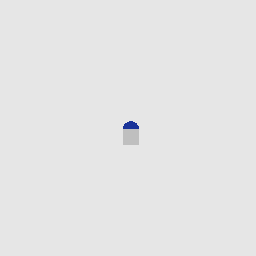

In [28]:
mediapy.show_image(env_states[0].observation["image"][1])

In [2]:
from omni_epic.envs.base import EnvBase
from omni_epic.jax2d.scene import add_rectangle_to_scene


class TestEnv(EnvBase):
	def __init__(self):
		super().__init__()

		obstacle_position = jnp.array([10.0, 5.0])
		self.init_state, (_, self.obstacle_idx) = add_rectangle_to_scene(
			self.init_state,
			self.static_sim_params,
			position=obstacle_position,
			dimensions=jnp.array([2.0, 2.0]),
			color=jnp.array([0.0, 0.2, 0.2]),
		)

		self.init_state = self.remove_polygon(self.init_state, self.floor_idx)

	@partial(jax.jit, static_argnames=("self",))
	def reset(self, key):
		state = super().reset()

		# Set initial position of the robot
		position = jax.random.uniform(key, (2,), minval=1.0, maxval=15.0)
		state = self.set_polygon_position(state, self.robot_idx, position)

		return state

	@partial(jax.jit, static_argnames=("self",))
	def step(self, state, action, key):
		actions = jnp.zeros(
			self.static_sim_params.num_joints + self.static_sim_params.num_thrusters
		)

		actions = self.apply_action(actions, action)
		state, reward, terminated, truncated, info = super().step(state, actions)

		return state, reward, terminated, truncated, info

	@partial(jax.jit, static_argnames=("self",))
	def get_task_rewards(self, state, manifolds, action):
		return {"distance_penalty": -self.dist_pp(state, self.robot_idx, self.ceiling_idx)}

	@partial(jax.jit, static_argnames=("self",))
	def get_terminated(self, state, manifolds, action):
		return ~self.collision_pp(manifolds, self.robot_idx, self.ceiling_idx)

	@partial(jax.jit, static_argnames=("self",))
	def get_truncated(self, state, manifolds, action):
		return jnp.array(False)

	@partial(jax.jit, static_argnames=("self",))
	def get_success(self, state, manifolds, action):
		return self.collision_pp(manifolds, self.robot_idx, self.ceiling_idx)


env = TestEnv()

## Check collisions

In [ ]:
state = env.reset(None)
action = jnp.zeros(env.static_sim_params.num_joints + env.static_sim_params.num_thrusters)
current_state, manifolds = env.step_fn(state, env.sim_params, action)
env.collision_pp(manifolds, env.robot_idx, env.obstacle_idx)